In [1]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot

Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [3]:
# roi (full cerebellum)
ROI_to_include = np.arange(1, 33)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation = atlas.read_data(model_name)

# make a mask of the cerebellum
ROI_mask = np.isin(parcelation, ROI_to_include).astype(int)

# get the indices of the voxels in the mask
ROI_indices = np.where(ROI_mask)[0]
len(ROI_indices)

5977

# Load data

- mdtb_1 - run: Data used to make G libray of tasks and to construct artificial batteries for parcellation
- mdtb_1 - all: Data used to estimate Vs within parcels in initial parcellation
- mdtb_2 - all: Data used to test parcellation predicition error

In [4]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [5]:
shared_indices = info_mdtb_2_all[info_mdtb_2_all['cond_name'].isin(info_mdtb_1_all['cond_name'])].index.tolist()
novel_indices = info_mdtb_2_all[~info_mdtb_2_all['cond_name'].isin(info_mdtb_1_all['cond_name'])].index.tolist()
data_mdtb_s2_all = data_mdtb_s2_all[:,shared_indices,:]


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and make rest a row of zeros


In [6]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')

# Get crossvalidated second moment matrix across subjects (GLib)

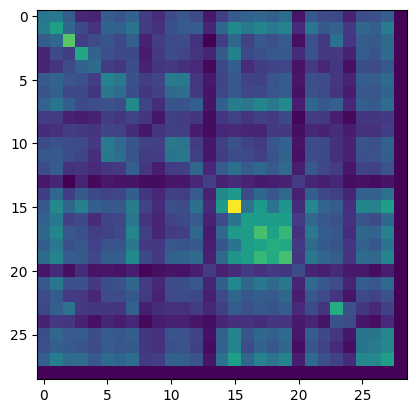

In [7]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib, cmap='viridis')

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [8]:
# make variables torch
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_test = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


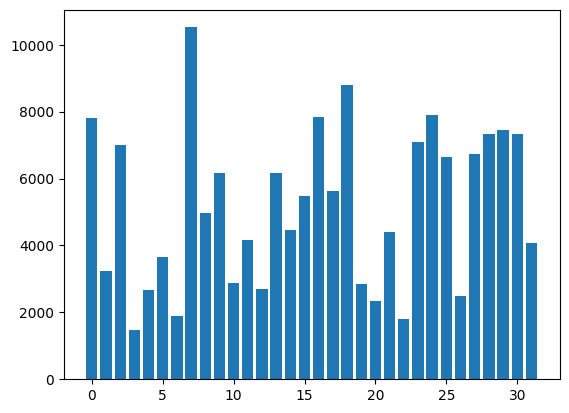

In [9]:
# estimate Vs for session 1 using s1 full data
full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

# estimate Vs for session 2 using s2 full data
full_vs_test = es.estimate_Vs(data_test,parcellation=parcelation,ROI_mask=ROI_mask)
full_vs_test = ut.center_matrix(full_vs_test,axis=0)
full_vs_test = ut.normalize_matrix(full_vs_test,axis=0)

# Get list of parcels ordered by size by counting voxel assignments across subjects (using Vs from session 1)
Us = es.estimate_Us(data_mdtb_s1_all, full_vs_train,method='correlation',hard=True)
parcel_counts = Us.sum(dim=(0,2))
sorted_parcels = pt.argsort(parcel_counts, descending=True).cpu().numpy()
parcel_counts = parcel_counts.cpu().numpy()
total_parcels = len(sorted_parcels)

plt.bar(range(len(parcel_counts)), parcel_counts)
plt.show()

In [10]:
# get dataframe that contains length of each regressor from mdtb-s1 and the indices of the regressor
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [13]:
# define ranges of battery and parcel sizes
battery_sizes = [3,4,5,6,7,8,10,14,16]
# parcel_sizes = [2,4,6,8,10,16,total_parcels]

parcel_sizes = [8,15,total_parcels]
# battery_sizes = [4,6]


In [14]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    # only pick the top n parcels 
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=10000,n_tasks=n_task,seed=1,replacement=False,rest_idx=28)
        # Make a artificial battery data + parcellation for each battery for each subject and evaluate on session 2
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,method='correlation')

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    



Processing parcel size: 8
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing battery size: 5
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing battery size: 6
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing battery size: 7
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing co

In [15]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cerebellum_MDTB_ses-01_ses-02_results_correlation.tsv')

# save to tsv
results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

In [16]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    # only pick the top n parcels 
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=10000,n_tasks=n_task,seed=1,replacement=False,rest_idx=28)
        # Make a artificial battery data + parcellation for each battery for each subject and evaluate on session 2
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,method='ridge')

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
        
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cerebellum_MDTB_ses-01_ses-02_results_ridge.tsv')

# save to tsv
results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

Processing parcel size: 8
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing battery size: 5
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing battery size: 6
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing battery size: 7
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing co

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

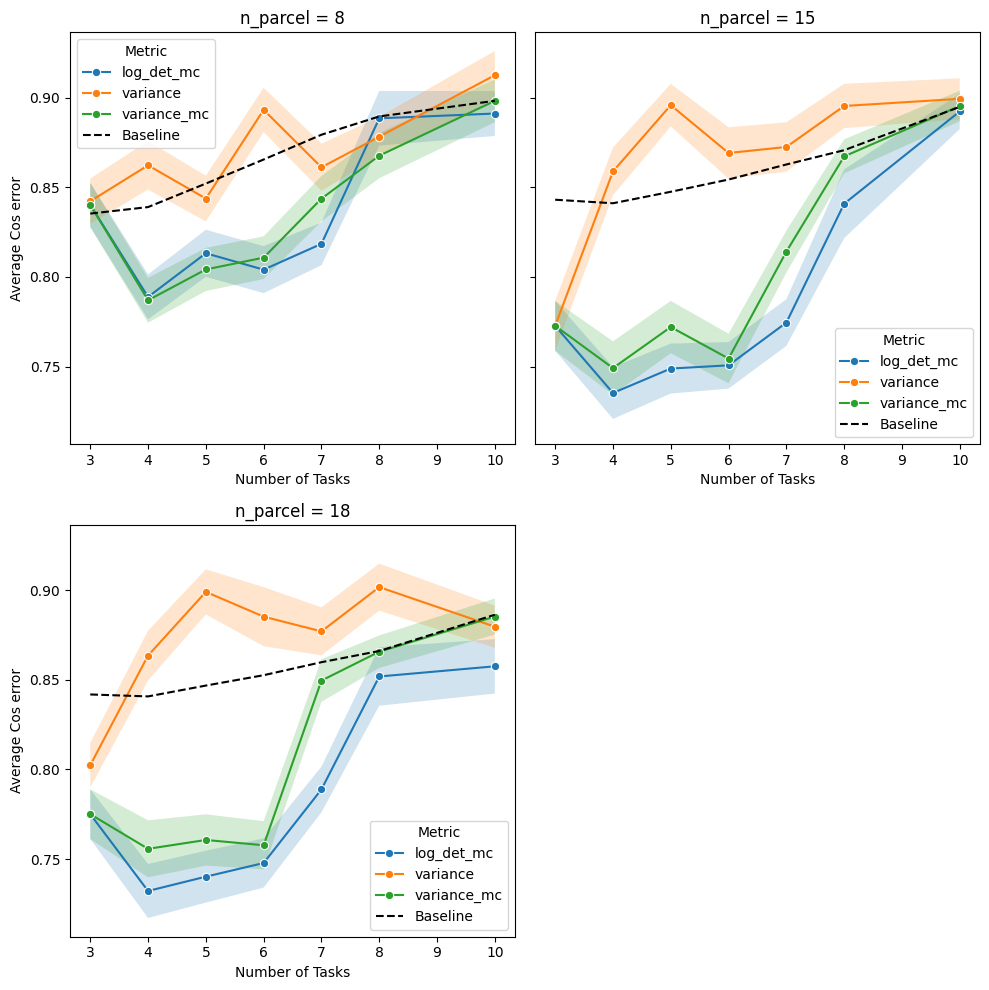

In [56]:
metrics = ["variance", "variance_mc", "log_det_mc"]
n_proposal_sets = 10
expanded_results_df = plot.resample_and_expand(results_df, metrics, n_proposal_sets)
aggregated_results_df = plot.compute_aggregated_results(expanded_results_df)
baseline_aggregated_df = plot.compute_baseline(results_df)
plot.plot_results(aggregated_results_df, baseline_aggregated_df)

In [59]:
D = ct.build_combinations(G_Lib, strategy='random',n_batteries=100000,n_tasks=5,seed=1,replacement=False,rest_idx=1)
len(D)


20326

In [68]:
# find row with the highest log_det_mc
best_row = D.loc[D['log_det_mc'].idxmax()]
combination = best_row['combination']
print(combination)


(2, 3, 17, 23, 1)


In [74]:
import OptimalBattery.estimate as et
n_parcel = 8
combination = list(combination)

regressor_list = ct.build_combination_regressors(combination,condition_df,8)
print(regressor_list)
YLib_subset = ct.average_regressors(data_train,regressor_list)
YLib_subset = ut.center_matrix(YLib_subset, axis=1)
YLib_subset = ut.normalize_matrix(YLib_subset, axis=1)

parcel_indices = sorted_parcels[:n_parcel]
VLib = full_vs_train[:,parcel_indices]
Vtest = full_vs_test[:,parcel_indices]

# get the Vs for the combination
VLib_subset = VLib[combination, :]
VLib_subset = ut.center_matrix(VLib_subset, axis=0)
VLib_subset = ut.normalize_matrix(VLib_subset, axis=0)


Ytest = data_test
Ytest = ut.center_matrix(Ytest, axis=1)
Ytest = ut.normalize_matrix(Ytest, axis=1)

Vtest = full_vs_test[:,parcel_indices]
Vtest = ut.center_matrix(Vtest, axis=0)
Vtest = ut.normalize_matrix(Vtest, axis=0)

U_hats = et.estimate_Us(YLib_subset, VLib_subset,method='ridge',hard=True)


# Compute yhat
yhat = pt.matmul(Vtest, U_hats)

# Compute cosine error across all voxels
if ROI_indices is not None:
    cosine_error_vox = 1 - pt.nansum(Ytest[:, :, ROI_indices] * yhat[:, :, ROI_indices], dim=1)
else:
    cosine_error_vox = 1 - pt.nansum(Ytest * yhat, dim=1)

# compute mean error per subject
cos_err = pt.nanmean(cosine_error_vox, dim=1)
cos_mean = pt.mean(cos_err)

print(cos_mean)
print(cos_err)

[[147, 176, 2], [119, 351, 148, 32, 3, 409], [249, 336, 220, 46, 162, 423], [52, 429, 81, 139, 400, 23], [436, 117, 59, 349, 30, 233]]
tensor(0.7967, device='cuda:0')
tensor([0.8073, 0.8459, 0.8172, 0.7896, 0.6338, 0.7264, 0.7841, 0.7478, 0.9296,
        0.7754, 0.7689, 0.7445, 0.7742, 0.7601, 0.9545, 0.8041, 0.8174, 0.8046,
        0.7589, 0.8054, 0.7956, 0.9034, 0.7207, 0.8523], device='cuda:0')
